# Attrition des Employés (Employee Churn)

## Prédiction du départ des employés dans une entreprise

### Objectif du projet

L’objectif de ce projet est de construire un modèle de Machine Learning capable de prédire si un employé risque de quitter l’entreprise ou non.

Cette prédiction permet au service des ressources humaines :
- d’anticiper les départs,
- de réduire le turnover,
- d’améliorer la satisfaction des employés,
- et de limiter les coûts liés au recrutement et à la formation.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Chargement du Dataset

Le dataset contient des informations sur les employés :
La variable cible est :
- `Attrition`
  - Yes → l’employé quitte l’entreprise
  - No → l’employé reste

In [2]:

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# Compréhension des données

In [3]:
df.shape

(1470, 35)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [6]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [7]:
df.duplicated().sum()

np.int64(0)

Le dataset ne contient ni valeurs manquantes ni doublons.

# Analyse Exploratoire des Données (EDA)

Cette étape permet de mieux comprendre les relations entre les variables et l’attrition des employés.

# Distribution de la variable cible

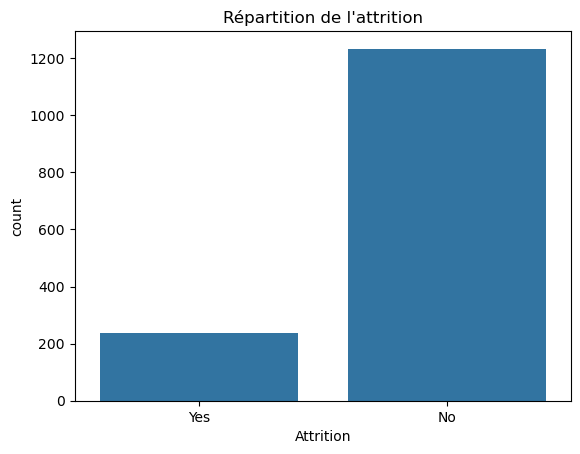

In [8]:
sns.countplot(x="Attrition", data=df)

plt.title("Répartition de l'attrition")
plt.show()

## Interprétation

On remarque que la majorité des employés restent dans l’entreprise. Le dataset est donc déséquilibré.

# Attrition et heures supplémentaires

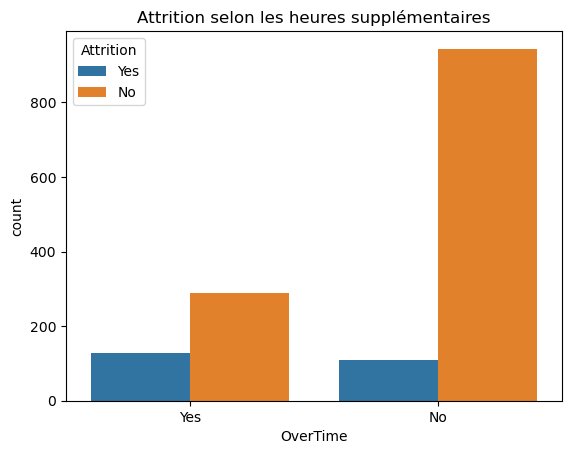

In [9]:
sns.countplot(x="OverTime", hue="Attrition", data=df)

plt.title("Attrition selon les heures supplémentaires")
plt.show()


Les employés effectuant des heures supplémentaires semblent quitter plus fréquemment l’entreprise.

# Salaire et attrition

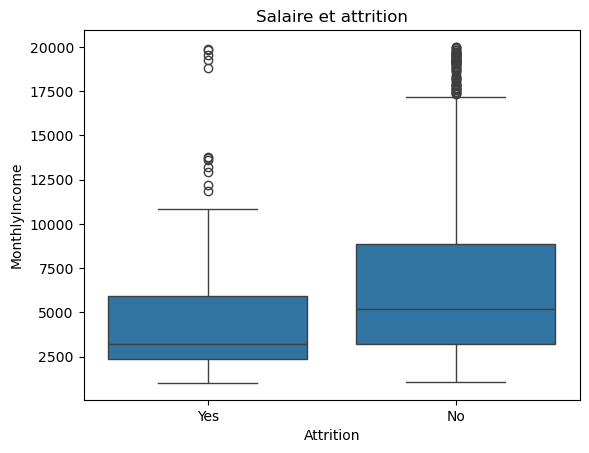

In [10]:
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)

plt.title("Salaire et attrition")
plt.show()

Les employés ayant un salaire plus faible semblent davantage susceptibles de quitter l’entreprise.

In [11]:
# Matrice de corrélation

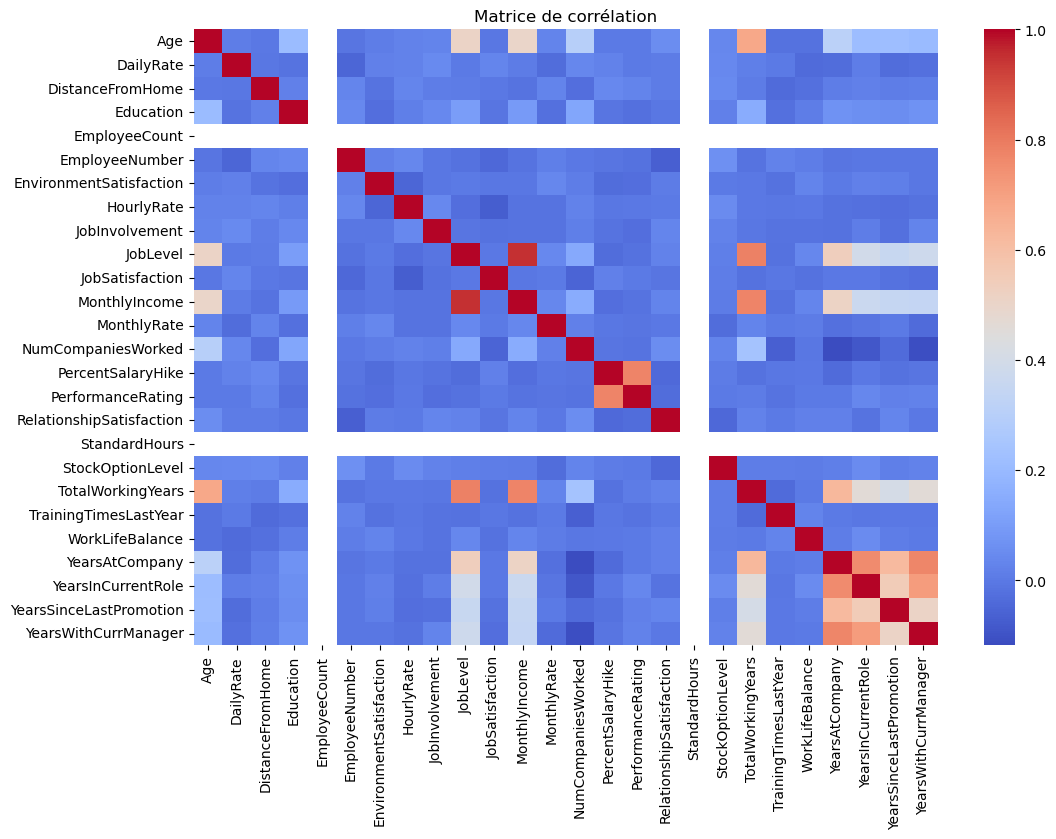

In [12]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title("Matrice de corrélation")
plt.show()


# Préparation des données

Cette étape consiste à transformer les données afin qu’elles puissent être utilisées par les modèles de Machine Learning.

# Suppression des colonnes inutiles

In [13]:
df = df.drop(
    ["EmployeeNumber", "EmployeeCount", "StandardHours", "Over18"],
    axis=1
)

# Encodage des variables catégorielles

Les modèles de Machine Learning ne peuvent pas traiter directement les données textuelles.

In [14]:
encoder = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = encoder.fit_transform(df[col])

# Séparation des variables

In [15]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

- `X` contient les variables explicatives.
- `y` contient la variable cible.

# Division Train/Test
Les données sont divisées en :
- 80% pour l’entraînement
- 20% pour le test

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Normalisation des données

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Modélisation

Nous comparons plusieurs modèles de classification afin d’identifier le plus performant.

# Régression Logistique

In [18]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

# Random Forest

In [19]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# Gradient Boosting

In [20]:
gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

# Évaluation des modèles

Nous utilisons :
- Accuracy
- F1-score
- Classification Report
- Matrice de confusion

In [21]:
def evaluate_model(name, y_pred):

    print(f"\n{name}")

    print("Accuracy:", accuracy_score(y_test, y_pred))

    print("F1-score:", f1_score(y_test, y_pred))

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    print("\nMatrice de confusion:\n")
    print(confusion_matrix(y_test, y_pred))

# Évaluation de la Régression Logistique

In [22]:
evaluate_model("Logistic Regression", y_pred_lr)


Logistic Regression
Accuracy: 0.8741496598639455
F1-score: 0.4931506849315068

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.97      0.93       247
           1       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294


Matrice de confusion:

[[239   8]
 [ 29  18]]


# Évaluation du Random Forest

In [23]:
evaluate_model("Random Forest", y_pred_rf)


Random Forest
Accuracy: 0.8367346938775511
F1-score: 0.2

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.46      0.13      0.20        47

    accuracy                           0.84       294
   macro avg       0.66      0.55      0.55       294
weighted avg       0.79      0.84      0.80       294


Matrice de confusion:

[[240   7]
 [ 41   6]]


# Évaluation du Gradient Boosting

In [24]:
evaluate_model("Gradient Boosting", y_pred_gb)


Gradient Boosting
Accuracy: 0.8435374149659864
F1-score: 0.28125

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.97      0.91       247
           1       0.53      0.19      0.28        47

    accuracy                           0.84       294
   macro avg       0.70      0.58      0.60       294
weighted avg       0.81      0.84      0.81       294


Matrice de confusion:

[[239   8]
 [ 38   9]]


# Importance des variables

Cette étape permet d’identifier les variables ayant le plus d’impact sur l’attrition.

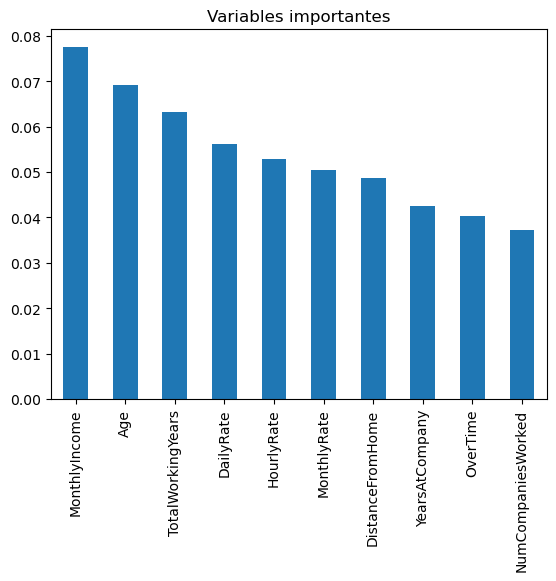

In [25]:
importances = rf.feature_importances_

features = pd.Series(
    importances,
    index=df.drop("Attrition", axis=1).columns
)

features.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Variables importantes")

plt.show()

# Interprétation des résultats

Les facteurs les plus influents dans le départ des employés sont :
- les heures supplémentaires
- le niveau de salaire
- la satisfaction au travail
- l’ancienneté
- l’environnement professionnel

# Analyse métier

Les résultats montrent que les employés surchargés,sous-payés, ou insatisfaits risquent le plus de quitter l’entreprise.

# Conclusion

Ce projet a permis de construire plusieurs modèles de Machine Learning capables de prédire l’attrition des employés.

Les résultats montrent que :
- les modèles d’ensemble comme Random Forest et Gradient Boosting offrent généralement les meilleures performances
- certaines variables humaines et organisationnelles influencent fortement le départ des employés.

Ce type d’analyse peut être utilisé dans un contexte réel afin d’améliorer la gestion des ressources humaines et la fidélisation des employés.